# Autoencoders: aprender a comprimir y reconstruir

> Cómo una red que debe reconstruir su propia entrada a través de un cuello de botella aprende una representación comprimida (espacio latente) sin necesidad de etiquetas. Autoencoders densos y convolucionales frente a PCA, autoencoders con ruido (*denoising*), detección de anomalías por el error de reconstrucción y los errores típicos: un cuello de botella demasiado ancho, medir mal la compresión o no saber dibujar lo reconstruido.
>
> **Requisitos previos:** [Redes neuronales densas](01-redes-neuronales-densas.ipynb) · [Redes convolucionales](03-redes-convolucionales.ipynb) · **Relacionado:** [Reducción de dimensionalidad](../04-machine-learning/02-reduccion-dimensionalidad.ipynb) · [GAN](08-gan.ipynb) · [Modelos de difusión](09-modelos-de-difusion.ipynb)

## 1. Idea clave

Un **autoencoder** es una red con dos partes: un **codificador** (*encoder*) que comprime la entrada en un vector pequeño, el **código** o **espacio latente**, y un **decodificador** (*decoder*) que intenta reconstruir la entrada original a partir de ese vector. Se entrena minimizando el **error de reconstrucción**, y como el objetivo es la propia entrada, **no necesita etiquetas** (aprendizaje no supervisado, o autosupervisado). El **cuello de botella** obliga a la red a quedarse solo con la información esencial.

Se usa para **reducir la dimensionalidad** y visualizar, **eliminar ruido**, **detectar anomalías** (lo que no se reconstruye bien no se parece a lo normal), comprimir y, en su versión probabilística (VAE), generar datos. Es la versión no lineal de [PCA](../04-machine-learning/02-reduccion-dimensionalidad.ipynb): con el mismo número de dimensiones suele reconstruir mejor, a cambio de entrenar una red.

## 2. Conceptos importantes

### 2.1. Estructura y función de pérdida

Sean $f$ el codificador y $g$ el decodificador. Para una entrada $\mathbf{x}$:

$$
\mathbf{z}=f(\mathbf{x})\in\mathbb{R}^{d},\qquad \hat{\mathbf{x}}=g(\mathbf{z}),\qquad
L=\frac{1}{n}\sum_{i=1}^{n}\lVert\mathbf{x}_i-\hat{\mathbf{x}}_i\rVert^2.
$$

La pérdida es el **error cuadrático medio** (MSE) entre la entrada y su reconstrucción (con píxeles en $[0,1]$ también se usa la entropía cruzada binaria). La salida del decodificador suele llevar una sigmoide para que la reconstrucción esté en el mismo rango que la entrada. La dimensión del código $d$ es el hiperparámetro principal. Si $d$ es **menor** que la dimensión de entrada (*undercomplete*), la red debe comprimir; si es igual o mayor (*overcomplete*), puede aprender la **identidad** (copiar la entrada) y no aprende nada útil salvo que se regularice.

### 2.2. Relación con PCA

Un autoencoder con activaciones lineales y pérdida MSE aprende el mismo subespacio que las $d$ primeras componentes de [PCA](../04-machine-learning/02-reduccion-dimensionalidad.ipynb). Con activaciones no lineales puede capturar estructuras curvas que PCA, que es lineal, no puede, así que con el mismo $d$ reconstruye mejor (lo comprobamos en 3.2). PCA, en cambio, tiene solución cerrada (sin entrenar) y es determinista.

### 2.3. Autoencoders convolucionales

Para imágenes, el codificador usa convoluciones con *stride* (o *pooling*) que reducen el tamaño espacial, y el decodificador las **convoluciones transpuestas** (`ConvTranspose2d`) o capas de aumento de tamaño (*upsampling*), que lo recuperan. Aprovechan la estructura espacial ([CNN](03-redes-convolucionales.ipynb)) y necesitan menos parámetros que uno denso. El código es un tensor $(C\times H'\times W')$ en vez de un vector.

### 2.4. Medir la compresión

La **razón de compresión** es el número de valores de la entrada dividido por el número de valores del código. Una imagen de $28\times28=784$ valores con un código de 32 se comprime 24,5:1. Cuidado con los autoencoders convolucionales: un código de $32\times7\times7=1\,568$ valores sería mayor que la entrada de 784, es decir, no comprime nada. Hay que contar **todos** los valores del código, no solo el número de canales.

### 2.5. Variantes

- ***Denoising*** (con ruido): se corrompe la entrada y se pide reconstruir la **limpia**, lo que fuerza a aprender la estructura de los datos en vez de copiar.
- **Dispersos** (*sparse*) y **contractivos**: añaden una penalización al código o al jacobiano para regularizar.
- **Variacionales** (VAE): el código no es un punto, sino una **distribución** (media y varianza) regularizada para parecerse a una normal; permite muestrear códigos y **generar** datos nuevos (relación con las [GAN](08-gan.ipynb) y los [modelos de difusión](09-modelos-de-difusion.ipynb)).
- ***Stacked* / preentrenamiento**: apilar autoencoders para preentrenar redes profundas; hoy en desuso frente al aprendizaje supervisado con datos y normalización.

### 2.6. Detección de anomalías

Se entrena el autoencoder **solo con datos normales**. Lo normal se reconstruye bien (error bajo); un caso anómalo, que la red nunca ha visto, se reconstruye peor (error alto). Se fija un **umbral** sobre el error de reconstrucción (elegido con datos normales de validación) y se señala como anomalía lo que lo supera. La calidad se mide con la curva ROC/AUC si hay anomalías etiquetadas.

## 3. Código

Usamos **Fashion-MNIST** (60 000 imágenes de $28\times28$ en escala de grises para entrenamiento y 10 000 para test; 10 tipos de prendas). Los píxeles se dejan en $[0,1]$ (sin estandarizar, porque la salida lleva sigmoide). Separamos 5 000 imágenes de validación; en test se evalúa el error de reconstrucción. Las etiquetas **no se usan** para entrenar: solo para colorear gráficos y evaluar la detección de anomalías.

In [1]:
import contextlib
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cudnn.deterministic = True                 # resultados reproducibles en GPU (algo más lento)
torch.backends.cudnn.benchmark = False

### 3.1. Datos

In [2]:
with contextlib.redirect_stderr(io.StringIO()):          # silencia las barras de descarga
    entrenamiento = datasets.FashionMNIST("data", train=True, download=True)
    prueba = datasets.FashionMNIST("data", train=False, download=True)
clases = entrenamiento.classes

X = entrenamiento.data.float().div(255).unsqueeze(1)      # (N, 1, 28, 28) en [0, 1]
y = entrenamiento.targets
X_test = prueba.data.float().div(255).unsqueeze(1)
y_test = prueba.targets
orden = torch.randperm(len(X), generator=torch.Generator().manual_seed(42))
X_train, y_train = X[orden[:55000]], y[orden[:55000]]
X_val = X[orden[55000:]]
print(f"entrenamiento {tuple(X_train.shape)}, validación {tuple(X_val.shape)}, test {tuple(X_test.shape)}; rango [{X.min():.0f}, {X.max():.0f}]")

entrenamiento (55000, 1, 28, 28), validación (5000, 1, 28, 28), test (10000, 1, 28, 28); rango [0, 1]


### 3.2. Autoencoder denso frente a PCA

Un autoencoder denso (784 → 256 → $d$ → 256 → 784) con 15 épocas de Adam. Variamos la dimensión del código $d$ y comparamos el MSE de reconstrucción en test con el de PCA con las mismas $d$ componentes. Incluimos $d=784$ (código igual que la entrada).

In [3]:
class Autoencoder(nn.Module):
    def __init__(self, codificador, decodificador):
        super().__init__()
        self.codificador, self.decodificador = codificador, decodificador
    def forward(self, x):
        return self.decodificador(self.codificador(x))

def autoencoder_denso(d, ocultas=256):
    cod = nn.Sequential(nn.Flatten(), nn.Linear(784, ocultas), nn.ReLU(), nn.Linear(ocultas, d))
    dec = nn.Sequential(nn.Linear(d, ocultas), nn.ReLU(), nn.Linear(ocultas, 784), nn.Sigmoid(), nn.Unflatten(1, (1, 28, 28)))
    return Autoencoder(cod, dec)

def entrenar(modelo, epocas=15, ruido=0.0, datos=None, lr=1e-3, semilla=0):
    datos = X_train if datos is None else datos
    modelo.to(device)
    opt = torch.optim.Adam(modelo.parameters(), lr=lr)
    cargador = DataLoader(TensorDataset(datos), batch_size=128, shuffle=True, generator=torch.Generator().manual_seed(semilla))
    for _ in range(epocas):
        modelo.train()
        for (x,) in cargador:
            x = x.to(device)
            entrada = (x + ruido * torch.randn_like(x)).clamp(0, 1) if ruido > 0 else x     # entrada corrompida (denoising)
            opt.zero_grad()
            F.mse_loss(modelo(entrada), x).backward()                                         # se reconstruye la imagen LIMPIA
            opt.step()
    return modelo

def error_mse(modelo, datos, ruido=0.0):
    modelo.eval()
    total = 0.0
    with torch.no_grad():
        for i in range(0, len(datos), 2000):
            x = datos[i:i + 2000].to(device)
            entrada = (x + ruido * torch.randn_like(x)).clamp(0, 1) if ruido > 0 else x
            total += F.mse_loss(modelo(entrada), x, reduction="sum").item()
    return total / datos.numel()

X_train_plano, X_test_plano = X_train.view(-1, 784).numpy(), X_test.view(-1, 784).numpy()
filas, ae_densos = {}, {}
for d in [2, 8, 32, 128, 784]:
    torch.manual_seed(0)
    ae_densos[d] = entrenar(autoencoder_denso(d))
    pca = PCA(n_components=d, random_state=0).fit(X_train_plano)
    reconstruido = pca.inverse_transform(pca.transform(X_test_plano))
    filas[f"d = {d}"] = {"compresión": f"{784 / d:.1f}:1", "MSE autoencoder": error_mse(ae_densos[d], X_test), "MSE PCA": ((reconstruido - X_test_plano) ** 2).mean()}
pd.DataFrame(filas).T

,compresión,MSE autoencoder,MSE PCA
d = 2,392.0:1,0.028444,0.046096
d = 8,98.0:1,0.014458,0.026606
d = 32,24.5:1,0.009196,0.015144
d = 128,6.1:1,0.006874,0.006313
d = 784,1.0:1,0.005595,0.0


Con códigos pequeños el autoencoder reconstruye mucho mejor que PCA con las mismas dimensiones: con $d=2$ el error es 0,028 frente a 0,046 (−38 %), con $d=8$ es 0,014 frente a 0,027 y con $d=32$ 0,0092 frente a 0,0151. Al subir $d$ la ventaja desaparece: con $d=128$ el error de PCA (0,0063) ya es algo menor que el del autoencoder (0,0069 tras 15 épocas), y con $d=784$ PCA reconstruye **exactamente** (error 0) mientras el autoencoder, sin necesidad de copiar la entrada, se queda en 0,0056. Más dimensiones siempre reconstruyen mejor, lo cual **no significa** que el código sea mejor: sin cuello de botella la red no está obligada a comprimir (4.2).

Veamos las reconstrucciones de 8 imágenes de test con distintos tamaños de código:

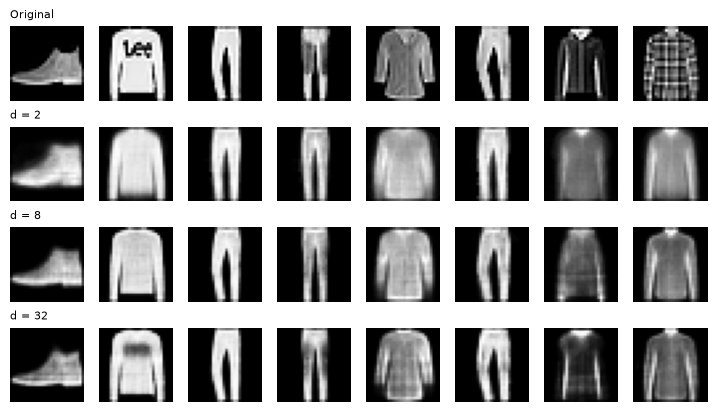

In [4]:
def a_imagen(t):                                          # (N, 1, 28, 28) en la GPU -> (N, 28, 28) en la CPU, en [0, 1]
    return t.detach().cpu().squeeze(1).clamp(0, 1).numpy()

muestras = X_test[:8]
filas_fig = [("Original", muestras)]
for d in [2, 8, 32]:
    ae_densos[d].eval()
    with torch.no_grad():
        filas_fig.append((f"d = {d}", ae_densos[d](muestras.to(device))))

fig, axes = plt.subplots(len(filas_fig), 8, figsize=(9, 5))
for fila, (titulo, imgs) in enumerate(filas_fig):
    for col, img in enumerate(a_imagen(imgs)):
        axes[fila, col].imshow(img, cmap="gray"); axes[fila, col].axis("off")
    axes[fila, 0].set_title(titulo, fontsize=8, loc="left")
plt.show()

Con $d=2$ las prendas son manchas reconocibles pero muy borrosas; con 8 se distinguen formas y con 32 la reconstrucción es buena aunque algo suave: el MSE favorece imágenes **borrosas** (promedia posibilidades) y pierde los detalles finos.

### 3.3. El espacio latente

Con $d=2$ podemos dibujar el código de las imágenes de test coloreadas por su clase (las etiquetas no se usaron para entrenar).

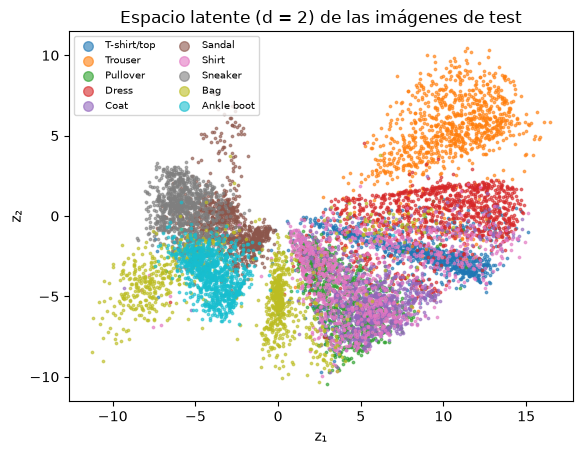

In [5]:
ae_densos[2].eval()
with torch.no_grad():
    Z = ae_densos[2].codificador(X_test.to(device)).cpu().numpy()
fig, ax = plt.subplots(figsize=(6.5, 4.8))
for k, nombre in enumerate(clases):
    sel = (y_test == k).numpy()
    ax.scatter(Z[sel, 0], Z[sel, 1], s=3, label=nombre, alpha=0.6)
ax.set_xlabel("z₁"); ax.set_ylabel("z₂"); ax.set_title("Espacio latente (d = 2) de las imágenes de test")
ax.legend(markerscale=4, fontsize=7, ncol=2)
plt.show()

Sin ver nunca una etiqueta, el autoencoder agrupa las prendas parecidas: el calzado (sandalia, zapatilla, bota) queda a la izquierda, separado de la ropa; los pantalones forman un grupo propio arriba a la derecha y los bolsos aparecen en dos zonas. Las camisetas, jerséis, abrigos y camisas se solapan (se parecen mucho en 2 dimensiones). Es la utilidad de la representación latente para visualizar y para análisis posteriores ([UMAP y t-SNE](../04-machine-learning/02-reduccion-dimensionalidad.ipynb) hacen algo parecido sin red).

### 3.4. Autoencoder convolucional

Codificador: dos convoluciones de *stride* 2 (el lado pasa de 28 a 14 y a 7) y una convolución final a $c$ canales; decodificador simétrico con convoluciones transpuestas. El código tiene $c\times7\times7$ valores. Probamos $c=1$, 4 y 16 (49, 196 y 784 valores: compresión 16:1, 4:1 y 1:1).

In [6]:
def autoencoder_convolucional(c):
    cod = nn.Sequential(nn.Conv2d(1, 16, 3, 2, 1), nn.ReLU(), nn.Conv2d(16, 32, 3, 2, 1), nn.ReLU(), nn.Conv2d(32, c, 3, 1, 1))
    dec = nn.Sequential(nn.ConvTranspose2d(c, 32, 3, 1, 1), nn.ReLU(), nn.ConvTranspose2d(32, 16, 3, 2, 1, output_padding=1), nn.ReLU(),
                        nn.ConvTranspose2d(16, 1, 3, 2, 1, output_padding=1), nn.Sigmoid())
    return Autoencoder(cod, dec)

filas, ae_conv = {}, {}
for c in [1, 4, 16]:
    torch.manual_seed(0)
    ae_conv[c] = entrenar(autoencoder_convolucional(c))
    filas[f"c = {c}"] = {"valores en el código": c * 49, "compresión": f"{784 / (c * 49):.1f}:1",
                         "parámetros": sum(p.numel() for p in ae_conv[c].parameters()), "MSE test": error_mse(ae_conv[c], X_test)}
pd.DataFrame(filas).T.astype({"valores en el código": int, "parámetros": int})

,valores en el código,compresión,parámetros,MSE test
c = 1,49,16.0:1,10178,0.010414
c = 4,196,4.0:1,11909,0.003836
c = 16,784,1.0:1,18833,0.001687


El convolucional con **196 valores** en el código (compresión 4:1) tiene un MSE de 0,0038, mejor que el denso con $d=128$ (0,0069) y con muchos menos parámetros (11 909 frente a unos 468 mil). Con 49 valores (16:1) el error es 0,0104, entre el del denso con $d=8$ (0,0145) y con $d=32$ (0,0092). Con $c=16$ el código tiene 784 valores, **los mismos que la entrada**: reconstruye casi a la perfección (0,0017), pero no comprime nada (2.4).

### 3.5. *Denoising*: reconstruir lo limpio a partir de lo sucio

Entrenamos dos autoencoders convolucionales ($c=4$): uno normal (entrada limpia) y otro con ruido gaussiano de desviación 0,4 sumado a la entrada (el objetivo sigue siendo la imagen limpia). Los evaluamos con entradas con ruido y sin él (MSE respecto a la imagen limpia). Como referencia, el error de la propia imagen con ruido respecto a la limpia.

MSE de la imagen con ruido respecto a la limpia (sin autoencoder): 0.0849
                   autoencoder normal  autoencoder denoising
entrada limpia                 0.0038                 0.0114
entrada con ruido              0.0399                 0.0134


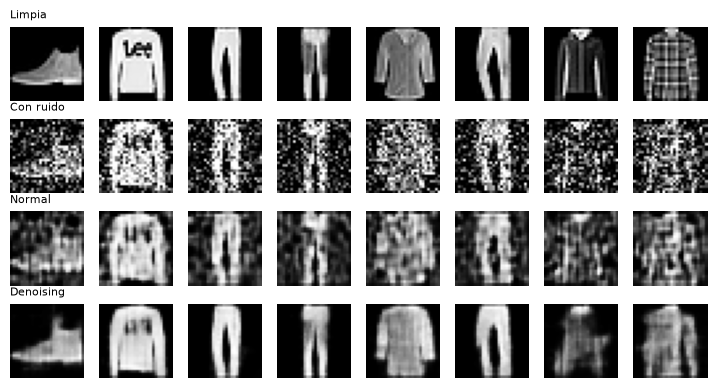

In [7]:
torch.manual_seed(0)
ae_normal = entrenar(autoencoder_convolucional(4))
torch.manual_seed(0)
ae_denoising = entrenar(autoencoder_convolucional(4), ruido=0.4)

torch.manual_seed(1)
ruido_test = (X_test + 0.4 * torch.randn_like(X_test)).clamp(0, 1)
tabla = pd.DataFrame({"autoencoder normal": {"entrada limpia": error_mse(ae_normal, X_test), "entrada con ruido": error_mse(ae_normal, X_test, ruido=0.4)},
                      "autoencoder denoising": {"entrada limpia": error_mse(ae_denoising, X_test), "entrada con ruido": error_mse(ae_denoising, X_test, ruido=0.4)}})
print(f"MSE de la imagen con ruido respecto a la limpia (sin autoencoder): {F.mse_loss(ruido_test, X_test).item():.4f}")
print(tabla.round(4).to_string())

filas_fig = [("Limpia", X_test[:8]), ("Con ruido", ruido_test[:8])]
for nombre, modelo in [("Normal", ae_normal), ("Denoising", ae_denoising)]:
    modelo.eval()
    with torch.no_grad():
        filas_fig.append((nombre, modelo(ruido_test[:8].to(device))))
fig, axes = plt.subplots(len(filas_fig), 8, figsize=(9, 4.6))
for fila, (titulo, imgs) in enumerate(filas_fig):
    for col, img in enumerate(a_imagen(imgs)):
        axes[fila, col].imshow(img, cmap="gray"); axes[fila, col].axis("off")
    axes[fila, 0].set_title(titulo, fontsize=8, loc="left")
plt.show()

El ruido solo ya aleja la imagen de la limpia con un MSE de ≈ 0,085. El autoencoder normal, que nunca vio ruido, lo reduce algo por el mero cuello de botella (0,040) pero reproduce parte de él; el *denoising* lo baja a **0,013**, tres veces menos, porque aprendió a descartar lo que no es estructura de la imagen. La contrapartida está en la entrada limpia: el *denoising* reconstruye algo peor (0,011 frente a 0,0038), porque se entrenó para "suavizar".

### 3.6. Detección de anomalías

Entrenamos un autoencoder denso ($d=16$) **solo con prendas de vestir** (camiseta, pantalón, jersey, vestido, abrigo y camisa: clases 0–4 y 6). En test, el calzado y los bolsos (clases 5, 7, 8 y 9) son las "anomalías", que el modelo nunca ha visto. Medimos el error de reconstrucción de cada imagen y el AUC para separar anomalías de normales.

Entrenamiento: 32939 imágenes de prendas (6 clases)
Error medio: normales 0.0096 | anomalías 0.0438
AUC (anomalía frente a normal): 0.979
AUC por clase anómala: {'Sandal': 0.979, 'Sneaker': 0.982, 'Bag': 0.962, 'Ankle boot': 0.993}


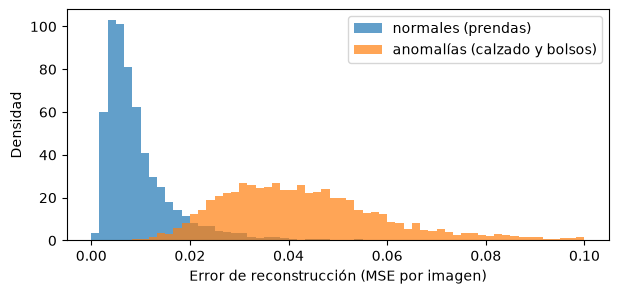

In [8]:
normales = [0, 1, 2, 3, 4, 6]
solo_normales = X_train[torch.isin(y_train, torch.tensor(normales))]
torch.manual_seed(0)
ae_anomalias = entrenar(autoencoder_denso(16), datos=solo_normales)

def error_por_imagen(modelo, datos):
    modelo.eval()
    errores = []
    with torch.no_grad():
        for i in range(0, len(datos), 2000):
            x = datos[i:i + 2000].to(device)
            errores.append(((modelo(x) - x) ** 2).mean((1, 2, 3)).cpu())
    return torch.cat(errores).numpy()

errores = error_por_imagen(ae_anomalias, X_test)
es_anomalia = ~torch.isin(y_test, torch.tensor(normales)).numpy()
print(f"Entrenamiento: {len(solo_normales)} imágenes de prendas ({len(normales)} clases)")
print(f"Error medio: normales {errores[~es_anomalia].mean():.4f} | anomalías {errores[es_anomalia].mean():.4f}")
print(f"AUC (anomalía frente a normal): {roc_auc_score(es_anomalia, errores):.3f}")
print("AUC por clase anómala:", {clases[c]: round(roc_auc_score(es_anomalia[(y_test.numpy() == c) | ~es_anomalia], errores[(y_test.numpy() == c) | ~es_anomalia]), 3) for c in [5, 7, 8, 9]})

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(errores[~es_anomalia], bins=60, range=(0, 0.1), alpha=0.7, label="normales (prendas)", density=True)
ax.hist(errores[es_anomalia], bins=60, range=(0, 0.1), alpha=0.7, label="anomalías (calzado y bolsos)", density=True)
ax.set_xlabel("Error de reconstrucción (MSE por imagen)"); ax.set_ylabel("Densidad"); ax.legend()
plt.show()

El error medio de las anomalías (0,044) es **4,6 veces mayor** que el de las prendas normales (0,0096), y el AUC es 0,979: con un autoencoder pequeño y solo datos normales se detectan casi todas. Entre las clases anómalas, la zapatilla, la sandalia y la bota se detectan con AUC > 0,97; el bolso, que tiene más variedad, es la más difícil (0,962). El umbral se elegiría con el error de datos **normales** de validación (por ejemplo, el percentil 99) y se ajustaría según el coste de las falsas alarmas.

## 4. Parámetros importantes y errores comunes

### 4.1. Parámetros que conviene conocer

| Parámetro | Qué controla | Consejo |
|---|---|---|
| **Dimensión del código** $d$ (o canales del cuello) | Cuánto se comprime | Pequeña para forzar a aprender estructura; mira el error y también la utilidad del código |
| **Profundidad y anchura** | Capacidad de codificador y decodificador | Simétricos; más capacidad = reconstruye mejor, pero puede copiar sin aprender |
| **Función de salida y pérdida** | Coherencia con el rango de los datos | Sigmoide + MSE o BCE si los datos están en $[0,1]$; lineal + MSE si están estandarizados |
| **Ruido de entrada** (*denoising*) | Regularización | Desviación 0,1–0,5 para imágenes en $[0,1]$ |
| **Épocas, tasa de aprendizaje** | Entrenamiento | Como siempre ([regularización](02-entrenamiento-y-regularizacion.ipynb)); vigila el error de validación |
| **Umbral de anomalía** | Falsas alarmas frente a anomalías perdidas | Percentil alto del error en datos normales de validación |

### 4.2. Errores comunes

- **Cuello de botella demasiado ancho.** Con $d$ igual o mayor que la entrada la red puede aprender la identidad: el error baja pero el código no aporta nada (3.2, $d=784$ y 3.4, $c=16$). Compara siempre con un modelo que comprime de verdad.
- **Medir mal la compresión.** Cuenta todos los valores del código (canales × alto × ancho), no solo los canales (2.4). En una práctica con imágenes de $224\times224\times3$ un código de $28\times28\times64=50\,176$ valores se comprime solo 3:1.
- **Tomar un error de reconstrucción bajo por un código útil.** El error baja al aumentar $d$ aunque el código sea peor; evalúa en la tarea posterior (clasificación, visualización, detección).
- **No poder dibujar lo reconstruido.** Las reconstrucciones salen como tensores `(N, 1, 28, 28)` en la GPU: hay que pasarlas a la CPU, quitar el canal y limitarlas a $[0,1]$ antes de `imshow`, o falla (demo siguiente). Un dibujo incorrecto puede hacer perder más tiempo que el propio modelo.
- **Imágenes borrosas.** El MSE favorece reconstrucciones suaves; no es un fallo del modelo. Para detalle fino se usan pérdidas perceptuales o modelos generativos ([GAN](08-gan.ipynb), [difusión](09-modelos-de-difusion.ipynb)).
- **Detectar anomalías con un autoencoder demasiado potente.** Si generaliza tan bien que reconstruye también lo anómalo, el error no separa. Controla la capacidad y comprueba con anomalías conocidas.
- **Elegir el umbral con datos anómalos del test.** Se calibra solo con datos normales de validación.
- **Entrenar y evaluar el *denoising* con ruidos distintos.** Si el ruido real no se parece al simulado, no funcionará igual.

#### Demo: dibujar una reconstrucción

Error al dibujar el tensor directamente: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.


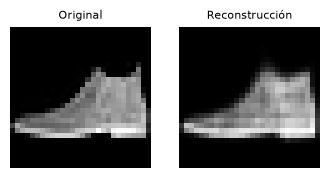

In [9]:
reconstruccion = ae_densos[32](X_test[:1].to(device))       # tensor (1, 1, 28, 28) en la GPU, con grafo de gradientes
try:
    plt.imshow(reconstruccion[0])                            # tensor en la GPU, con gradientes y de forma (1, 28, 28)
except TypeError as error:
    print("Error al dibujar el tensor directamente:", error)
plt.close("all")

fig, axes = plt.subplots(1, 2, figsize=(4, 2))
axes[0].imshow(X_test[0, 0], cmap="gray"); axes[0].set_title("Original", fontsize=8)
axes[1].imshow(reconstruccion[0, 0].detach().cpu().clamp(0, 1), cmap="gray"); axes[1].set_title("Reconstrucción", fontsize=8)
for ax in axes:
    ax.axis("off")
plt.show()

El primer error es de dispositivo (el tensor está en la GPU y tiene gradientes). Arreglado eso, fallaría la forma `(1, 28, 28)`. Hay que seleccionar el canal (`[0, 0]`) para que quede un array de $28\times28$ y llevarlo a la CPU sin gradientes (`.detach().cpu()`); `clamp(0, 1)` evita valores fuera de rango.

## 5. Comparación con métodos relacionados

| Método | Lineal | Entrenamiento | Reconstruye mejor con pocas dimensiones | Genera datos nuevos | Cuándo usarlo |
|---|---|---|---|---|---|
| **[PCA](../04-machine-learning/02-reduccion-dimensionalidad.ipynb)** | Sí | Ninguno (solución cerrada) | Peor (3.2) | No | Primera opción: rápido, determinista, interpretable |
| **Autoencoder denso** | No | Una red | Mejor con $d$ pequeño | No | Datos tabulares o vectores; detección de anomalías |
| **Autoencoder convolucional** | No | Una red | Mejor, con menos parámetros (3.4) | No | Imágenes: reducción, ruido, anomalías |
| ***Denoising* autoencoder** | No | Una red, con ruido | — (reconstruye lo limpio) | No | Eliminar ruido; regularizar |
| **VAE** | No | Una red, con pérdida probabilística | Algo peor (más borroso) | **Sí** (muestreando el código) | Generar o interpolar |
| **[GAN](08-gan.ipynb) / [difusión](09-modelos-de-difusion.ipynb)** | No | Redes adversarias / proceso de ruido | — | Sí, con más calidad | Generar imágenes realistas |
| **UMAP / t-SNE** | No | Optimización | — (solo visualizan) | No | Visualizar en 2D ([reducción de dimensionalidad](../04-machine-learning/02-reduccion-dimensionalidad.ipynb)) |

## 6. Referencias

### Fuentes

- Xiao, H., Rasul, K. y Vollgraf, R. (2017). *Fashion-MNIST: a novel image dataset for benchmarking machine learning algorithms*. arXiv:1708.07747. Origen del conjunto de datos, descargado con [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/stable/generated/torchvision.datasets.FashionMNIST.html).
- PyTorch: [`nn.ConvTranspose2d`](https://pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html), [`nn.Conv2d`](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html) y [`F.mse_loss`](https://pytorch.org/docs/stable/generated/torch.nn.functional.mse_loss.html). scikit-learn: [`PCA`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) y [`roc_auc_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html).

### Para saber más

- Hinton, G. E. y Salakhutdinov, R. R. (2006). [«Reducing the dimensionality of data with neural networks»](https://doi.org/10.1126/science.1127647). *Science*, 313(5786), 504–507. El artículo que popularizó los autoencoders profundos y su comparación con PCA.
- Kingma, D. P. y Welling, M. (2014). [«Auto-encoding variational Bayes»](https://arxiv.org/abs/1312.6114). *International Conference on Learning Representations (ICLR)*. Introduce el autoencoder variacional (VAE).